# EDA — Bloc B : Description univariée
**Projet :** ImmoVision 360 — Périmètre Élysée  
**Table :** `elysee_tabular`  
**Objectif :** Décrire chaque variable de la table individuellement avant tout croisement.  
**Avril 2026**

---
## 0. Imports et configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('[✓] Imports effectués')

[✓] Imports effectués


---
## 1. Connexion à PostgreSQL et chargement de `elysee_tabular`

In [2]:
load_dotenv()

DB_USER     = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = os.getenv('DB_PORT', '5432')
DB_NAME     = os.getenv('DB_NAME', 'immovision')

engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

df = pd.read_sql('SELECT * FROM elysee_tabular', engine)

print(f'[✓] Table chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes')
df.head(3)

[✓] Table chargée : 2625 lignes, 8 colonnes


,id,calculated_host_listings_count,availability_365,host_response_rate_num,room_type_code,host_response_time_code,standardization_score,neighborhood_impact_score
0,2871271,1,96,100.0,2,0.0,1,1
1,2785692,1,176,NaN,1,NaN,-1,-1
2,2892435,2,299,100.0,2,0.0,-1,-1


---
## 2. Traitement des valeurs manquantes

Toutes les valeurs manquantes sont remplacées par **−1**.  
**Convention :** dans l'ensemble de cette analyse, −1 signifie « information non disponible » et doit être distingué des 0 métier (par exemple, une disponibilité de 0 jour est un fait mesurable, pas une absence de données).

In [3]:
# Vérification avant remplacement
nan_avant = df.isnull().sum()
print('Valeurs manquantes par colonne (avant remplacement) :')
print(nan_avant[nan_avant > 0].to_string() if nan_avant.sum() > 0 else '  Aucune valeur manquante détectée.')

# Remplacement
df = df.fillna(-1)

print(f'\n[✓] Remplacement effectué — valeurs manquantes restantes : {df.isnull().sum().sum()}')

Valeurs manquantes par colonne (avant remplacement) :
host_response_rate_num     681
host_response_time_code    681

[✓] Remplacement effectué — valeurs manquantes restantes : 0


---
## 3. Description univariée — variable par variable

La colonne `id` est un identifiant d'annonce (entier unique par ligne). Elle ne constitue pas une mesure et n'est pas analysée statistiquement.  
Les 7 variables restantes sont décrites ci-dessous selon leur nature.

---
### 3.1 `calculated_host_listings_count` — Variable **quantitative**

**Définition :** nombre total d'annonces actives associées au même hôte sur la plateforme.  
**Rôle proxy :** concentration de l'offre entre peu d'acteurs (hypothèse économique A).

Effectif : 2625 annonces
Min      : 1
Médiane  : 3.0
Moy.     : 52.2
90e perc.: 141
Max      : 816


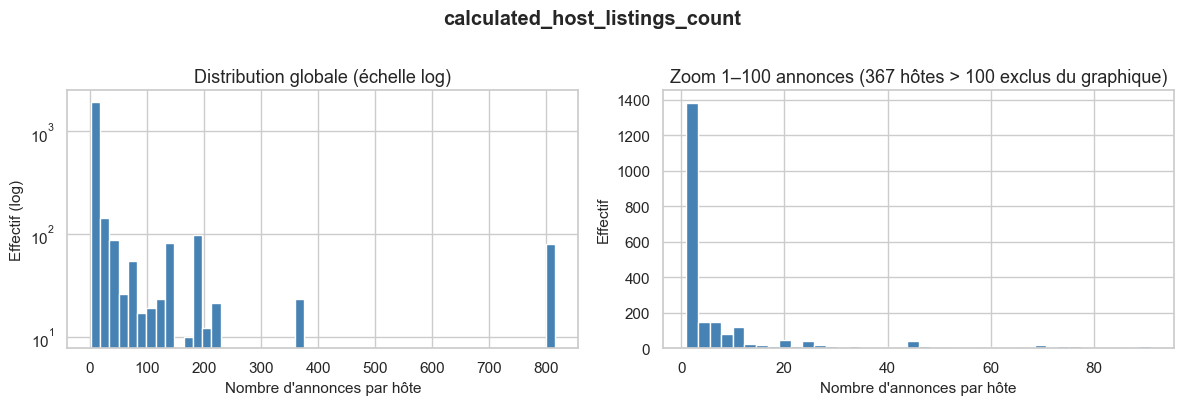


→ 367 hôte(s) possèdent plus de 100 annonces (valeurs extrêmes).


In [4]:
col = 'calculated_host_listings_count'
serie = df[col]

# Statistiques descriptives
stats = serie.describe(percentiles=[.25, .5, .75, .90])
print(f'Effectif : {int(stats["count"])} annonces')
print(f'Min      : {serie.min()}')
print(f'Médiane  : {serie.median()}')
print(f'Moy.     : {serie.mean():.1f}')
print(f'90e perc.: {serie.quantile(0.90):.0f}')
print(f'Max      : {serie.max()}')

# Histogramme (plafonné à 100 pour lisibilité ; les valeurs > 100 sont signalées)
seuil = 100
n_extremes = (serie > seuil).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme global (log scale sur Y pour voir la longue queue)
axes[0].hist(serie, bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Distribution globale (échelle log)')
axes[0].set_xlabel('Nombre d\'annonces par hôte')
axes[0].set_ylabel('Effectif (log)')

# Histogramme zoomé (zoom sur 1–100)
axes[1].hist(serie[serie <= seuil], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title(f'Zoom 1–{seuil} annonces ({n_extremes} hôtes > {seuil} exclus du graphique)')
axes[1].set_xlabel('Nombre d\'annonces par hôte')
axes[1].set_ylabel('Effectif')

plt.suptitle('calculated_host_listings_count', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\n→ {n_extremes} hôte(s) possèdent plus de {seuil} annonces (valeurs extrêmes).')

**Interprétation :** La distribution est fortement asymétrique vers la droite : la grande majorité des hôtes ne gère qu'une poignée d'annonces, tandis qu'un petit nombre d'acteurs concentre un volume disproportionné. Ce profil est caractéristique d'une offre dominée par quelques gestionnaires professionnels ou agences, aux côtés d'une masse d'hôtes occasionnels. Les valeurs très élevées (signalées ci-dessus) feront l'objet d'une attention particulière dans le Bloc C lors des croisements.

---
### 3.2 `availability_365` — Variable **quantitative**

**Définition :** nombre de jours déclarés disponibles à la réservation sur une année glissante (0 = aucun jour disponible, 365 = disponible toute l'année).  
**Rôle proxy :** intensité d'utilisation commerciale du logement.

Effectif : 2625 annonces
Min      : 0
Médiane  : 183.0
Moy.     : 174.7
Max      : 365

Annonces à 0 jour de dispo  : 587 (22.4%)
Annonces à 365 jours de dispo: 57 (2.2%)


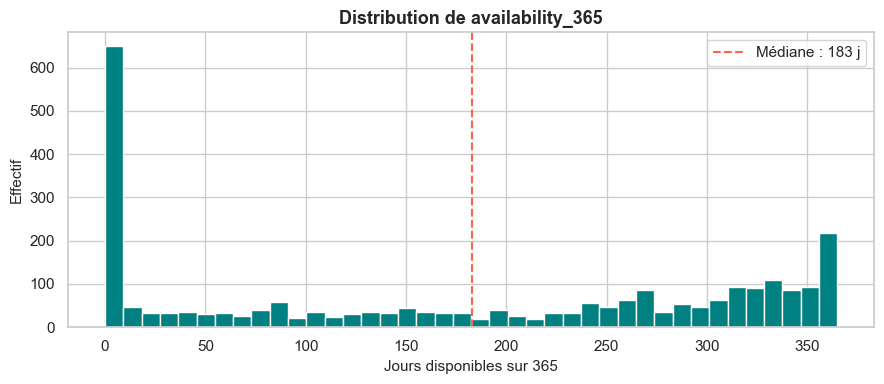

In [5]:
col = 'availability_365'
serie = df[col]

stats = serie.describe(percentiles=[.25, .5, .75])
print(f'Effectif : {int(stats["count"])} annonces')
print(f'Min      : {serie.min()}')
print(f'Médiane  : {serie.median()}')
print(f'Moy.     : {serie.mean():.1f}')
print(f'Max      : {serie.max()}')
print(f'\nAnnonces à 0 jour de dispo  : {(serie == 0).sum()} ({(serie == 0).mean()*100:.1f}%)')
print(f'Annonces à 365 jours de dispo: {(serie == 365).sum()} ({(serie == 365).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(serie, bins=40, color='teal', edgecolor='white')
ax.axvline(serie.median(), color='tomato', linestyle='--', linewidth=1.5, label=f'Médiane : {serie.median():.0f} j')
ax.set_title('Distribution de availability_365', fontweight='bold')
ax.set_xlabel('Jours disponibles sur 365')
ax.set_ylabel('Effectif')
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation :** La distribution présente deux pics caractéristiques : une concentration d'annonces à 0 jour (logements temporairement fermés ou gérés par blocs) et un second pic vers 365 jours (annonces en location quasi-permanente). La médiane permet de situer le comportement central. Les annonces entièrement disponibles toute l'année constituent un signal fort d'usage commercial plutôt que de partage occasionnel.

---
### 3.3 `host_response_rate_num` — Variable **quantitative**

**Définition :** pourcentage de messages auxquels l'hôte répond (0 à 100). Après remplacement des NaN, les valeurs −1 correspondent à des hôtes sans historique de réponse renseigné.  
**Rôle proxy :** professionnalisme et réactivité de l'hôte.

Effectif total     : 2625
Dont −1 (inconnu)  : 681 (25.9%)
Valeurs exploitables : 1944
Médiane (sans −1)  : 100.0%
Moy.    (sans −1)  : 92.1%
Min     (sans −1)  : 0.0
Max     (sans −1)  : 100.0


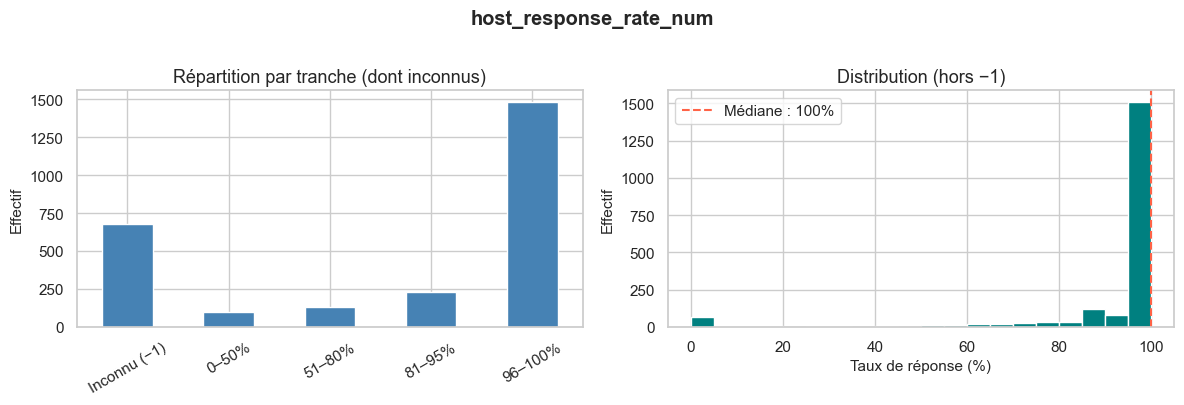

In [6]:
col = 'host_response_rate_num'
serie = df[col]

# Séparation −1 (non disponibles) vs valeurs métier
n_inconnu = (serie == -1).sum()
serie_valide = serie[serie != -1]

print(f'Effectif total     : {len(serie)}')
print(f'Dont −1 (inconnu)  : {n_inconnu} ({n_inconnu/len(serie)*100:.1f}%)')
print(f'Valeurs exploitables : {len(serie_valide)}')
print(f'Médiane (sans −1)  : {serie_valide.median():.1f}%')
print(f'Moy.    (sans −1)  : {serie_valide.mean():.1f}%')
print(f'Min     (sans −1)  : {serie_valide.min()}')
print(f'Max     (sans −1)  : {serie_valide.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Effectifs par tranche (toutes valeurs dont −1)
tranches = pd.cut(serie, bins=[-2, -0.5, 50, 80, 95, 100],
                  labels=['Inconnu (−1)', '0–50%', '51–80%', '81–95%', '96–100%'])
tranches.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Répartition par tranche (dont inconnus)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Effectif')
axes[0].tick_params(axis='x', rotation=30)

# Histogramme sur valeurs valides uniquement
axes[1].hist(serie_valide, bins=20, color='teal', edgecolor='white')
axes[1].axvline(serie_valide.median(), color='tomato', linestyle='--', linewidth=1.5,
                label=f'Médiane : {serie_valide.median():.0f}%')
axes[1].set_title('Distribution (hors −1)')
axes[1].set_xlabel('Taux de réponse (%)')
axes[1].set_ylabel('Effectif')
axes[1].legend()

plt.suptitle('host_response_rate_num', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :** La majorité des hôtes disposant d'un taux renseigné affichent une réactivité très élevée, proche de 100 %. La proportion d'hôtes sans information (−1) est à surveiller car elle peut biaiser les comparaisons dans le Bloc C. Les hôtes à taux très faible constituent une minorité et peuvent signaler des annonces abandonnées ou mal gérées.

---
### 3.4 `room_type_code` — Variable **catégorielle nominale**

**Définition :** type de location codé en entier.  

| Code | Catégorie |
|------|-----------|
| 0 | Chambre partagée (Shared room) |
| 1 | Chambre privée (Private room) |
| 2 | Logement entier (Entire home/apt) |
| 3 | Chambre hôtelière (Hotel room) |
| −1 | Inconnu / non reconnu |

Les codes n'ont **aucun ordre naturel** entre eux — il s'agit d'un étiquetage.

Effectifs par catégorie :
  Chambre
privée         :   297  (11.3%)
  Logement
entier        :  2247  (85.6%)
  Chambre
hôtelière      :    81  (3.1%)


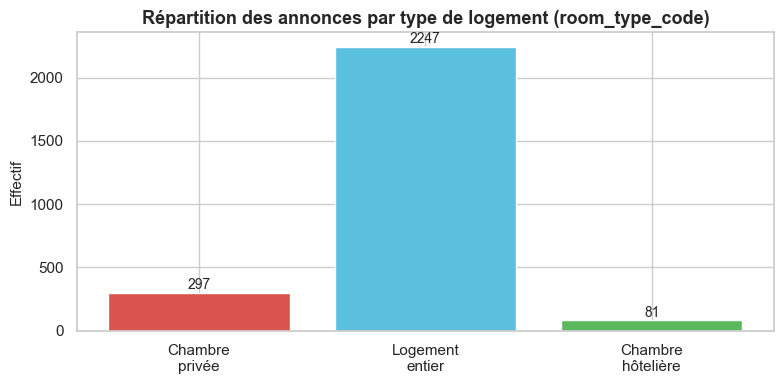

In [7]:
col = 'room_type_code'
labels = {-1: 'Inconnu', 0: 'Chambre\npartagée', 1: 'Chambre\nprivée',
          2: 'Logement\nentier', 3: 'Chambre\nhôtelière'}

counts = df[col].value_counts().sort_index()
counts.index = [labels.get(i, str(i)) for i in counts.index]

print('Effectifs par catégorie :')
for cat, n in counts.items():
    print(f'  {cat:<22} : {n:>5}  ({n/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values,
              color=['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e', '#aaaaaa'][:len(counts)],
              edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_title('Répartition des annonces par type de logement (room_type_code)', fontweight='bold')
ax.set_ylabel('Effectif')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Interprétation :** Les logements entiers dominent vraisemblablement l'offre du périmètre Élysée, ce qui est cohérent avec un marché orienté vers le tourisme et les voyages d'affaires. Les chambres partagées et hôtelières sont marginales. Cette structure confirmera ou infirmera l'hypothèse de privatisation du parc (question 3 du Bloc A).

---
### 3.5 `host_response_time_code` — Variable **ordinale**

**Définition :** délai habituel de réponse de l'hôte, codé en entier. L'ordre est significatif : plus le code est petit, plus la réponse est rapide.

| Code | Signification | Vitesse |
|------|---------------|---------|
| 0 | Dans l'heure | ← Plus rapide |
| 1 | En quelques heures | |
| 2 | Dans la journée | |
| 3 | En plusieurs jours | ← Plus lent |
| −1 | Inconnu | |

Effectifs dans l'ordre métier :
  Inconnu
(−1)                   :   681  (25.9%)
  Dans
l'heure (0)               :  1356  (51.7%)
  Quelques
heures (1)            :   244  (9.3%)
  Dans la
journée (2)            :   255  (9.7%)
  Plusieurs
jours (3)            :    89  (3.4%)


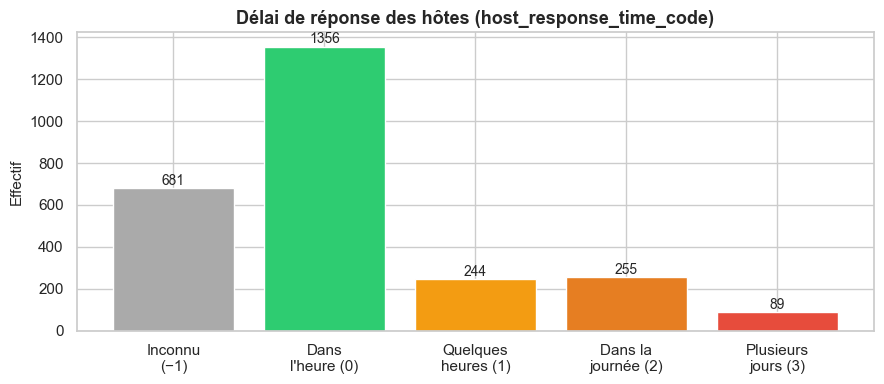

In [8]:
col = 'host_response_time_code'
labels_ord = {
    -1: 'Inconnu\n(−1)',
     0: 'Dans\nl\'heure (0)',
     1: 'Quelques\nheures (1)',
     2: 'Dans la\njournée (2)',
     3: 'Plusieurs\njours (3)'
}

# Ordre métier : −1 en dernier pour ne pas polluer la lecture ordinale
ordre = [-1, 0, 1, 2, 3]
counts = df[col].value_counts().reindex(ordre, fill_value=0)

print('Effectifs dans l\'ordre métier :')
for code, n in counts.items():
    print(f'  {labels_ord[code]:<30} : {n:>5}  ({n/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
couleurs = ['#aaaaaa', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar([labels_ord[c] for c in ordre], counts.values,
              color=couleurs, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_title('Délai de réponse des hôtes (host_response_time_code)', fontweight='bold')
ax.set_ylabel('Effectif')
plt.tight_layout()
plt.show()

**Interprétation :** La répartition entre les délais de réponse permet de qualifier le niveau de professionnalisme moyen des hôtes. Une forte concentration sur le code 0 (dans l'heure) indiquerait une gestion automatisée ou professionnelle, cohérente avec l'hypothèse B. La part des −1 (inconnus) doit être notée car ces hôtes seront exclus des croisements impliquant cette variable.

---
### 3.6 `standardization_score` — Score du projet (trichotomique)

**Définition :** score issu de l'analyse visuelle par IA des photos de logements.

| Score | Signification |
|-------|---------------|
| 1 | Appartement industrialisé (style catalogue, standardisé) |
| 0 | Appartement personnel (objets de vie, chaleureux) |
| −1 | Autre / non analysé (image absente, corrompue, non pertinente) |

Distribution de standardization_score :
  Industrialisé (1)         :  1050  (40.0%)
  Personnel (0)             :   792  (30.2%)
  Non analysé (−1)          :   783  (29.8%)

  → 783 annonces (29.8%) sont en "non analysé" (−1).
     Elles seront exclues des comparaisons dans le Bloc C.


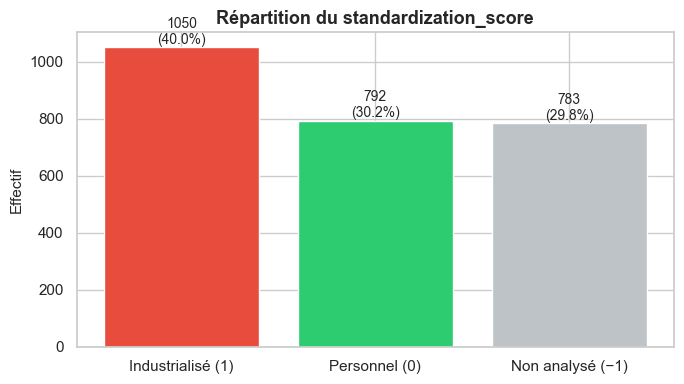

In [9]:
col = 'standardization_score'
labels_sc = {1: 'Industrialisé (1)', 0: 'Personnel (0)', -1: 'Non analysé (−1)'}
ordre = [1, 0, -1]

counts = df[col].value_counts().reindex(ordre, fill_value=0)
total = len(df)

print('Distribution de standardization_score :')
for code, n in counts.items():
    print(f'  {labels_sc[code]:<25} : {n:>5}  ({n/total*100:.1f}%)')

# Part des −1
n_inconnu = counts.get(-1, 0)
print(f'\n  → {n_inconnu} annonces ({n_inconnu/total*100:.1f}%) sont en "non analysé" (−1).')
print(f'     Elles seront exclues des comparaisons dans le Bloc C.')

fig, ax = plt.subplots(figsize=(7, 4))
couleurs_sc = ['#e74c3c', '#2ecc71', '#bdc3c7']
bars = ax.bar([labels_sc[c] for c in ordre], counts.values,
              color=couleurs_sc, edgecolor='white')
for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Répartition du standardization_score', fontweight='bold')
ax.set_ylabel('Effectif')
plt.tight_layout()
plt.show()

**Interprétation :** Ce score synthétise la dimension visuelle de l'hypothèse C (standardisation des logements). La proportion de logements classés « industrialisés » (score = 1) versus « personnels » (score = 0) donne une première lecture de l'état du parc. La part des −1 doit être signalée avec transparence car elle représente les annonces pour lesquelles l'IA n'a pas pu se prononcer — ces lignes ne disparaissent pas du dataset mais sont mises à l'écart pour les analyses comparatives.

---
### 3.7 `neighborhood_impact_score` — Score du projet (trichotomique)

**Définition :** score issu de l'analyse NLP des commentaires voyageurs.

| Score | Signification |
|-------|---------------|
| 1 | Hôtélisé (check-in automatique, peu de contact humain, gestion d'agence) |
| 0 | Voisinage naturel (lien avec l'hôte, conseils de quartier, vie locale) |
| −1 | Autre / ambigu (texte absent, trop court, non exploitable) |

Distribution de neighborhood_impact_score :
  Hôtélisé (1)              :  1004  (38.2%)
  Voisinage naturel (0)     :   799  (30.4%)
  Non analysé (−1)          :   822  (31.3%)

  → 822 annonces (31.3%) sont en "non analysé" (−1).


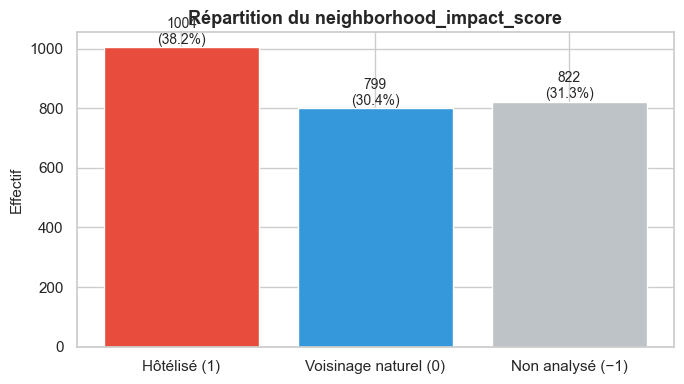

In [10]:
col = 'neighborhood_impact_score'
labels_ni = {1: 'Hôtélisé (1)', 0: 'Voisinage naturel (0)', -1: 'Non analysé (−1)'}
ordre = [1, 0, -1]

counts = df[col].value_counts().reindex(ordre, fill_value=0)
total = len(df)

print('Distribution de neighborhood_impact_score :')
for code, n in counts.items():
    print(f'  {labels_ni[code]:<25} : {n:>5}  ({n/total*100:.1f}%)')

n_inconnu = counts.get(-1, 0)
print(f'\n  → {n_inconnu} annonces ({n_inconnu/total*100:.1f}%) sont en "non analysé" (−1).')

fig, ax = plt.subplots(figsize=(7, 4))
couleurs_ni = ['#e74c3c', '#3498db', '#bdc3c7']
bars = ax.bar([labels_ni[c] for c in ordre], counts.values,
              color=couleurs_ni, edgecolor='white')
for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Répartition du neighborhood_impact_score', fontweight='bold')
ax.set_ylabel('Effectif')
plt.tight_layout()
plt.show()

**Interprétation :** Ce score quantifie la dimension sociale de l'hypothèse B. La proportion de logements classés « hôtélisés » (score = 1) révèle dans quelle mesure les commentaires des voyageurs décrivent une expérience impersonnelle et automatisée, sans lien humain avec l'hôte. Une majorité de scores 1 signalerait une rupture du tissu social local, ce que la Mairie cherche précisément à documenter.

---
## 4. Synthèse du Bloc B

Le tableau ci-dessous récapitule les informations clés issues de la description univariée.

In [11]:
synthese = pd.DataFrame({
    'Variable': [
        'calculated_host_listings_count',
        'availability_365',
        'host_response_rate_num',
        'room_type_code',
        'host_response_time_code',
        'standardization_score',
        'neighborhood_impact_score'
    ],
    'Nature': [
        'Quantitative', 'Quantitative', 'Quantitative',
        'Nominale', 'Ordinale', 'Trichotomique', 'Trichotomique'
    ],
    'Effectif valide': [
        len(df),
        len(df),
        (df['host_response_rate_num'] != -1).sum(),
        len(df),
        (df['host_response_time_code'] != -1).sum(),
        (df['standardization_score'] != -1).sum(),
        (df['neighborhood_impact_score'] != -1).sum()
    ],
    'Valeurs −1 (inconnu)': [
        0,
        0,
        (df['host_response_rate_num'] == -1).sum(),
        (df['room_type_code'] == -1).sum(),
        (df['host_response_time_code'] == -1).sum(),
        (df['standardization_score'] == -1).sum(),
        (df['neighborhood_impact_score'] == -1).sum()
    ]
})

print(synthese.to_string(index=False))

                      Variable        Nature  Effectif valide  Valeurs −1 (inconnu)
calculated_host_listings_count  Quantitative             2625                     0
              availability_365  Quantitative             2625                     0
        host_response_rate_num  Quantitative             1944                   681
                room_type_code      Nominale             2625                     0
       host_response_time_code      Ordinale             1944                   681
         standardization_score Trichotomique             1842                   783
     neighborhood_impact_score Trichotomique             1803                   822


**Prochaine étape — Bloc C :** les croisements entre variables planifiés dans la feuille de route (Bloc A) sont exécutés sur ce même DataFrame. Les lignes à −1 sont exclues au cas par cas selon la variable concernée, avec mention explicite dans chaque commentaire.